In [1]:
DATASET_ROOT = "/content/dataset"
OUT_ROOT     = f"{DATASET_ROOT}/__outputs"

import os, pathlib
pathlib.Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)
print("DATASET_ROOT:", DATASET_ROOT)
print("OUT_ROOT    :", OUT_ROOT)

DATASET_ROOT: /content/dataset
OUT_ROOT    : /content/dataset/__outputs


In [2]:
!pip install -q pandas pyarrow ijson

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.3/148.3 kB 3.7 MB/s eta 0:00:00


In [3]:
import json, ijson, pandas as pd, os, pathlib
from typing import Any, List, Dict

def load_json_auto(path: str):
    """Smart JSON loader supporting list/dict and large files."""
    with open(path, "rb") as f:
        first = None
        while True:
            c = f.read(1)
            if not c: break
            if c.strip():
                first = c.decode("utf-8", "ignore")
                break
        f.seek(0)
        if first == "[":
            return list(ijson.items(f, "item"))
        return json.load(f)

def normalize_any(obj: Any, record_path=None, meta=None, sep=".") -> pd.DataFrame:
    """Universal JSON flattener."""
    if isinstance(obj, list):
        if record_path:
            return pd.json_normalize(obj, record_path=record_path, meta=meta or [], sep=sep, errors="ignore")
        return pd.json_normalize(obj, sep=sep)
    if isinstance(obj, dict):
        if record_path:
            return pd.json_normalize(obj, record_path=record_path, meta=meta or [], sep=sep, errors="ignore")
        for k in ("data","items","documents","records","rows","articles","speeches"):
            if isinstance(obj.get(k), list):
                return pd.json_normalize(obj[k], sep=sep)
        return pd.json_normalize(obj, sep=sep)
    return pd.DataFrame()

def save_df(df: pd.DataFrame, out_dir: str, name: str):
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, f"{name}.csv")
    pq_path  = os.path.join(out_dir, f"{name}.parquet")
    df.to_csv(csv_path, index=False)
    try:
        df.to_parquet(pq_path, index=False)
    except Exception:
        pass
    print(f"Saved: {csv_path}  (rows={len(df)})")
    return csv_path, pq_path

In [4]:
import glob
from typing import Iterable

def _pm_url(u):
    if isinstance(u, str):
        return {"raw": u, "composed": u, "query": ""}
    if not isinstance(u, dict): return {"raw":"", "composed":"", "query":""}
    raw = u.get("raw","")
    host = u.get("host",[])
    path = u.get("path",[])
    scheme = u.get("protocol","")
    if isinstance(host, list): host = ".".join(host)
    if isinstance(path, list): path = "/".join(path)
    composed = raw or (f"{scheme}://{host}/{path}".replace("//","/").replace(":/","://").strip("/"))
    q = u.get("query",[])
    if isinstance(q, list):
        query = "&".join([f"{d.get('key','')}={d.get('value','')}" for d in q if d])
    else:
        query = ""
    if query and "?" not in composed:
        composed = composed + "?" + query
    return {"raw":raw, "composed":composed, "query":query}

def _pm_headers(h):
    if isinstance(h, list):
        return "\n".join([f"{d.get('key','')}: {d.get('value','')}" for d in h if d])
    return ""

def _pm_body(b):
    if not isinstance(b, dict): return ""
    mode = b.get("mode")
    if mode == "raw": return b.get("raw","")
    if mode in ("formdata","urlencoded"):
        arr = b.get(mode,[])
        if isinstance(arr, list):
            return "\n".join([f"{d.get('key','')}={d.get('value','')}" for d in arr])
    if mode == "file": return str(b.get("file",{}).get("src",""))
    return ""

def _pm_walk(items, parents) -> Iterable[Dict]:
    for it in items or []:
        name = it.get("name","")
        if "item" in it and "request" not in it:
            yield from _pm_walk(it.get("item",[]), parents+[name])
            continue
        req = it.get("request",{}) or {}
        url = _pm_url(req.get("url"))
        method = req.get("method","")
        yield {
            "folder_path": " / ".join(parents) if parents else "",
            "item_name": name,
            "method": method,
            "url_raw": url["raw"],
            "url": url["composed"],
            "query": url["query"],
            "headers": _pm_headers(req.get("header",[])),
            "body": _pm_body(req.get("body")),
            "description": (req.get("description") or it.get("description") or "")
        }

def parse_postman_dir(pm_dir: str, out_dir: str, person: str):
    pattern = os.path.join(pm_dir, "*_postman_collection.json")
    files = sorted(glob.glob(pattern))
    if not files:
        print(f"[{person}] No Postman collections found.")
        return None
    frames = []
    for fp in files:
        with open(fp,"r",encoding="utf-8") as f:
            obj = json.load(f)
        name = obj.get("info",{}).get("name") or os.path.basename(fp)
        rows = list(_pm_walk(obj.get("item",[]), []))
        df = pd.DataFrame(rows)
        df.insert(0,"collection", name)
        df.insert(1,"source_file", os.path.basename(fp))
        frames.append(df)
    df_all = pd.concat(frames, ignore_index=True)
    save_df(df_all, out_dir, f"{person}__postman_requests")
    api_dict = (
        df_all.assign(sig=df_all["method"].fillna("")+" "+df_all["url"].fillna(""))
              .drop_duplicates(subset=["collection","sig"])
              [["collection","folder_path","item_name","method","url","query"]]
              .sort_values(["collection","folder_path","item_name"])
    )
    save_df(api_dict, out_dir, f"{person}__postman_api_dictionary")
    return df_all

In [5]:
import glob

def extract_person(person_dir: str, person: str):
    out_dir = os.path.join(OUT_ROOT, person)
    os.makedirs(out_dir, exist_ok=True)

    # ----- processed_data -----
    proc_dir = os.path.join(person_dir, "processed_data")
    if os.path.isdir(proc_dir):
        for fname, outname in [
            ("dataset_metadata.json" , "dataset_metadata"),
            ("processing_report.json", "processing_report"),
            ("structured_documents.json","structured_documents"),
            ("training_chunks.json"   ,"training_chunks"),
            ("validation_report.json","validation_report"),
        ]:
            fp = os.path.join(proc_dir, fname)
            if os.path.isfile(fp):
                obj = load_json_auto(fp)
                df  = normalize_any(obj)
                save_df(df, out_dir, f"{person}__{outname}")

        # Paragraph-level expansion
        sd = os.path.join(proc_dir, "structured_documents.json")
        if os.path.isfile(sd):
            try:
                obj = load_json_auto(sd)
                para = normalize_any(
                    obj,
                    record_path=["documents","sections","paragraphs"],
                    meta=[["documents","id"],["documents","title"],["documents","period"]],
                ).rename(columns={
                    "documents.id":"doc_id","documents.title":"doc_title",
                    "documents.period":"doc_period","text":"paragraph_text"
                })
                save_df(para, out_dir, f"{person}__structured_paragraphs")
            except Exception as e:
                print(f"[{person}] structured_documents not deeply nested:", e)

    # ----- raw_data -----
    raw_dir = os.path.join(person_dir, "raw_data")
    if os.path.isdir(raw_dir):
        for sub in ("metadata","supplementary_materials"):
            p = os.path.join(raw_dir, sub)
            if os.path.isdir(p):
                for fp in sorted(glob.glob(os.path.join(p, "*.json"))):
                    obj = load_json_auto(fp); df = normalize_any(obj)
                    save_df(df, out_dir, f"{person}__raw__{sub}__{os.path.splitext(os.path.basename(fp))[0]}")
        wiki = os.path.join(raw_dir, "wikipedia")
        if os.path.isdir(wiki):
            for fp in sorted(glob.glob(os.path.join(wiki, "*.json"))):
                obj = load_json_auto(fp); df = normalize_any(obj)
                save_df(df, out_dir, f"{person}__wikipedia__{os.path.splitext(os.path.basename(fp))[0]}")

        # Special: Queen Elizabeth speeches
        sp = os.path.join(raw_dir, "speeches")
        if os.path.isdir(sp):
            for fp in sorted(glob.glob(os.path.join(sp, "*.json"))):
                obj = load_json_auto(fp); df = normalize_any(obj)
                save_df(df, out_dir, f"{person}__speeches__{os.path.splitext(os.path.basename(fp))[0]}")
        sps = os.path.join(raw_dir, "speeches_supplement")
        if os.path.isdir(sps):
            for fp in sorted(glob.glob(os.path.join(sps, "*.json"))):
                obj = load_json_auto(fp); df = normalize_any(obj)
                save_df(df, out_dir, f"{person}__speeches_supplement__{os.path.splitext(os.path.basename(fp))[0]}")

    # ----- external_resources (Postman) -----
    ext_dir = os.path.join(person_dir, "external_resources")
    if os.path.isdir(ext_dir):
        parse_postman_dir(ext_dir, out_dir, person)

    print(f"[{person}] Extraction completed → {out_dir}")

In [6]:
PERSONS = ["du-fu", "elon_musk", "queen_elizabeth_ii"]
for p in PERSONS:
    pdir = os.path.join(DATASET_ROOT, p)
    if os.path.isdir(pdir):
        extract_person(pdir, p)
    else:
        print(f"Skip: {pdir} (not found)")

Saved: /content/dataset/__outputs/du-fu/du-fu__dataset_metadata.csv  (rows=1)
Saved: /content/dataset/__outputs/du-fu/du-fu__processing_report.csv  (rows=1)
Saved: /content/dataset/__outputs/du-fu/du-fu__structured_documents.csv  (rows=1496)
Saved: /content/dataset/__outputs/du-fu/du-fu__training_chunks.csv  (rows=3449)
Saved: /content/dataset/__outputs/du-fu/du-fu__validation_report.csv  (rows=1)
[du-fu] structured_documents not deeply nested: 'documents'
[du-fu] No Postman collections found.
[du-fu] Extraction completed → /content/dataset/__outputs/du-fu
Saved: /content/dataset/__outputs/elon_musk/elon_musk__dataset_metadata.csv  (rows=1)
Saved: /content/dataset/__outputs/elon_musk/elon_musk__processing_report.csv  (rows=1)
Saved: /content/dataset/__outputs/elon_musk/elon_musk__structured_documents.csv  (rows=48)
Saved: /content/dataset/__outputs/elon_musk/elon_musk__training_chunks.csv  (rows=96)
Saved: /content/dataset/__outputs/elon_musk/elon_musk__validation_report.csv  (rows=1)


In [8]:
import pandas as pd, os, glob

def load_if(path):
    return pd.read_csv(path) if os.path.isfile(path) else None

all_parts = []
for person in PERSONS:
    out_dir = os.path.join(OUT_ROOT, person)

    # training_chunks
    tc = load_if(os.path.join(out_dir, f"{person}__training_chunks.csv"))
    if tc is not None:
        rename = {"id":"chunk_id","chunk_id":"chunk_id","doc_id":"doc_id","document_id":"doc_id",
                  "name":"name","speaker":"name","period":"period","text":"text","content":"text",
                  "lang":"lang","language":"lang"}
        for k,v in rename.items():
            if k in tc.columns: tc = tc.rename(columns={k:v})
        keep = [c for c in ["chunk_id","doc_id","name","period","text","lang"] if c in tc.columns]
        for _, row in tc[keep].iterrows():
            all_parts.append(row.to_dict() | {"person": person})

    # structured_paragraphs
    sp = load_if(os.path.join(out_dir, f"{person}__structured_paragraphs.csv"))
    if sp is not None and "paragraph_text" in sp.columns:
        for _, row in sp.iterrows():
            all_parts.append({
                "doc_id": row.get("doc_id", ""),
                "doc_title": row.get("doc_title", ""),
                "doc_period": row.get("doc_period", ""),
                "text": row["paragraph_text"],
                "name": "",
                "period": row.get("doc_period",""),
                "lang": "",
                "person": person
            })

    # wikipedia
    for sub in ("biography","related_articles"):
        w = load_if(os.path.join(out_dir, f"{person}__wikipedia__{sub}.csv"))
        if w is not None:
            text_col = next((c for c in ("text","content","article","body","paragraph","extract") if c in w.columns), None)
            if text_col is None:
                w["__tmp_text"] = w.astype(str).agg(" ".join, axis=1)
                text_col = "__tmp_text"
            for _, row in w.iterrows():
                all_parts.append({
                    "doc_id": "",
                    "name": "",
                    "period": "",
                    "lang": "",
                    "text": row[text_col],
                    "person": person
                })

corpus = pd.DataFrame(all_parts) if all_parts else pd.DataFrame(columns=["doc_id","name","period","text","lang","person"])
corpus = corpus.dropna(subset=["text"])
corpus["text"] = corpus["text"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip()
corpus = corpus[corpus["text"].str.len()>0].drop_duplicates(subset=["text"])
save_df(corpus, OUT_ROOT, "corpus_for_retrieval")

Saved: /content/dataset/__outputs/corpus_for_retrieval.csv  (rows=3568)


('/content/dataset/__outputs/corpus_for_retrieval.csv',
 '/content/dataset/__outputs/corpus_for_retrieval.parquet')

In [9]:
txt_path = os.path.join(OUT_ROOT, "corpus_for_retrieval.txt")
with open(txt_path, "w", encoding="utf-8") as f:
    for t in corpus["text"]:
        f.write(t.replace("\n"," ")+"\n")
print("Saved:", txt_path)

Saved: /content/dataset/__outputs/corpus_for_retrieval.txt


# **TF-IDF Retrieval System**

In [41]:
from __future__ import annotations
import re, os, json, gc
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    import jieba
    _HAS_JIEBA = True
except Exception:
    _HAS_JIEBA = False

def zh_tokenize(text: str) -> List[str]:
    """Basic Chinese tokenizer. Prefer jieba if available; else char-level with filtering."""
    t = (text or "").strip()
    if not t:
        return []
    if _HAS_JIEBA:
        return [w.strip() for w in jieba.lcut(t) if w.strip()]
    return [ch for ch in re.findall(r"[\u4e00-\u9fff]", t)]

def en_tokenize(text: str) -> List[str]:
    t = (text or "").lower()
    return re.findall(r"[a-z0-9]+", t)

def mixed_tokenize(text: str) -> List[str]:
    """Mixed tokenizer: split CJK and non-CJK separately, then combine."""
    zh = zh_tokenize(text)
    en = en_tokenize(text)
    return zh + en

def normalize_space(s: str) -> str:
    return re.sub(r"\s+", " ", str(s or "")).strip()

def default_preprocess(text: str) -> str:
    """Light normalization prior to vectorizer analyzer."""
    t = normalize_space(text)
    t = t.replace("“", "\"").replace("”", "\"").replace("’", "'")
    return t

@dataclass
class SearchResult:
    doc_id: Any
    score: float
    meta: Dict[str, Any]

class TfidfRetrieval:
    def __init__(
        self,
        analyzer: str = "word",
        ngram_range: Tuple[int, int] = (1, 2),
        max_features: int = 50000,
        min_df: int = 2,
        use_idf: bool = True,
        smooth_idf: bool = True,
        lowercase: bool = False,
        tokenizer_mode: str = "mixed",
    ):
        self.tokenizer_mode = tokenizer_mode
        if tokenizer_mode == "en":
            analyzer_fn = lambda x: en_tokenize(default_preprocess(x))
        elif tokenizer_mode == "zh":
            analyzer_fn = lambda x: zh_tokenize(default_preprocess(x))
        else:
            analyzer_fn = lambda x: mixed_tokenize(default_preprocess(x))

        self.vectorizer = TfidfVectorizer(
            analyzer=analyzer_fn,
            ngram_range=ngram_range,
            max_features=max_features,
            min_df=min_df,
            use_idf=use_idf,
            smooth_idf=smooth_idf,
            lowercase=lowercase,
            norm="l2"
        )
        self.tfidf = None
        self.df = None
        self.inverted_index: Dict[str, List[int]] = {}

    def fit(self, df: pd.DataFrame, text_col: str = "text", id_col: str = "id") -> None:
        """
        df must contain at least [id_col, text_col].
        Optional meta columns (e.g., name, period, lang) are preserved.
        """
        assert text_col in df.columns and id_col in df.columns, f"{text_col}/{id_col} missing."
        self.df = df.copy()
        self.df[text_col] = self.df[text_col].astype(str).map(default_preprocess)
        texts = self.df[text_col].tolist()

        self.tfidf = self.vectorizer.fit_transform(texts)

        vocab = self.vectorizer.vocabulary_
        inv: Dict[str, List[int]] = {}
        X = self.tfidf.tocsc()
        for term, col_idx in vocab.items():
            rows = X.getcol(col_idx).nonzero()[0]
            inv[term] = rows.tolist()
        self.inverted_index = inv

        gc.collect()

    def save(self, folder: str) -> None:
        os.makedirs(folder, exist_ok=True)
        from joblib import dump
        dump(self.vectorizer, os.path.join(folder, "vectorizer.joblib"))
        dump(self.tfidf, os.path.join(folder, "tfidf_matrix.joblib"))
        self.df.to_parquet(os.path.join(folder, "corpus.parquet"), index=False)
        with open(os.path.join(folder, "inverted_index.json"), "w", encoding="utf-8") as f:
            json.dump(self.inverted_index, f, ensure_ascii=False)
        print(f"Model saved to {folder}")

    def load(self, folder: str) -> None:
        from joblib import load
        self.vectorizer = load(os.path.join(folder, "vectorizer.joblib"))
        self.tfidf = load(os.path.join(folder, "tfidf_matrix.joblib"))
        self.df = pd.read_parquet(os.path.join(folder, "corpus.parquet"))
        with open(os.path.join(folder, "inverted_index.json"), "r", encoding="utf-8") as f:
            self.inverted_index = json.load(f)
        print(f"Model loaded from {folder}")

    def expand_query(self, query: str, lang_hint: Optional[str] = None) -> List[str]:
        """
        Very lightweight expansion:
        - tokenize (respect lang hint if provided)
        - add frequent bigrams present in corpus vocabulary
        - optional synonym hooks (you can inject your dict)
        """
        q = normalize_space(query)
        if not q:
            return []

        if lang_hint == "en":
            toks = en_tokenize(q)
        elif lang_hint == "zh":
            toks = zh_tokenize(q)
        else:
            toks = mixed_tokenize(q)

        vocab = set(self.vectorizer.vocabulary_.keys())
        bigrams = []
        for i in range(len(toks) - 1):
            bi = toks[i] + " " + toks[i+1]
            if bi in vocab:
                bigrams.append(bi)

        expanded = toks + bigrams
        return expanded

    def search(
        self,
        query: str,
        top_k: int = 10,
        lang_hint: Optional[str] = None,
        text_col: str = "text",
        id_col: str = "id",
        rerank_phrase_boost: float = 0.15
    ) -> List[SearchResult]:
        """
        1) Expand query -> build a small candidate set via inverted index
        2) Cosine similarity over TF-IDF vectors
        3) Optional re-ranking: phrase/bigram matches boosted
        """
        assert self.tfidf is not None and self.df is not None, "Call fit/load first."

        expanded = self.expand_query(query, lang_hint=lang_hint)
        if not expanded:
            return []

        cand_idx = set()
        for tok in expanded:
            if tok in self.inverted_index:
                cand_idx.update(self.inverted_index[tok])
        if not cand_idx:
            cand_idx = set(range(self.tfidf.shape[0]))
        cand_idx = np.array(list(cand_idx), dtype=int)

        q_vec = self.vectorizer.transform([" ".join(expanded)])
        c_mat = self.tfidf[cand_idx]
        sim = cosine_similarity(q_vec, c_mat)[0]

        q_norm = normalize_space(query)
        boosts = np.zeros_like(sim)
        if rerank_phrase_boost > 0:
            texts = self.df.iloc[cand_idx][text_col].astype(str).tolist()
            for i, t in enumerate(texts):
                if q_norm and q_norm in t:
                    boosts[i] += rerank_phrase_boost

        final_scores = sim + boosts
        order = np.argsort(final_scores)[::-1][:top_k]
        rows = self.df.iloc[cand_idx[order]]

        results: List[SearchResult] = []
        for score, (_, row) in zip(final_scores[order], rows.iterrows()):
            meta = row.to_dict()
            results.append(SearchResult(doc_id=meta.get(id_col), score=float(score), meta=meta))
        return results

def build_from_csv(
    corpus_csv: str,
    text_col: str = "text",
    id_col: str = "id",
    tokenizer_mode: str = "mixed"
) -> TfidfRetrieval:
    df = pd.read_csv(corpus_csv)
    df = df.dropna(subset=[text_col]).copy()
    df[text_col] = df[text_col].astype(str).map(normalize_space)
    engine = TfidfRetrieval(tokenizer_mode=tokenizer_mode)
    engine.fit(df, text_col=text_col, id_col=id_col)
    return engine

# RAG Architecture Optimization

In [49]:
from __future__ import annotations
import os, time, re
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

try:
    from rank_bm25 import BM25Okapi
    _HAS_BM25 = True
except Exception:
    _HAS_BM25 = False

try:
    import faiss
    _HAS_FAISS = True
except Exception:
    _HAS_FAISS = False

try:
    import torch
    from sentence_transformers import SentenceTransformer, CrossEncoder
    _HAS_SBERT = True
    _HAS_XENC  = True
except Exception:
    _HAS_SBERT = False
    _HAS_XENC  = False

@dataclass
class Hit:
    score: float
    text: str
    meta: Dict[str, Any]


class ResultCache:
    def __init__(self, maxsize: int = 1024, ttl_sec: int = 600):
        self.maxsize = maxsize
        self.ttl = ttl_sec
        self._store: Dict[str, Tuple[float, Any]] = {}
        self._order: List[str] = []

    def _evict(self):
        while len(self._order) > self.maxsize:
            k = self._order.pop(0)
            self._store.pop(k, None)

    def get(self, key: str):
        now = time.time()
        v = self._store.get(key)
        if not v: return None
        ts, data = v
        if now - ts > self.ttl:
            self._store.pop(key)
            try: self._order.remove(key)
            except ValueError: pass
            return None
        try: self._order.remove(key)
        except ValueError: pass
        self._order.append(key)
        return data

    def set(self, key: str, data: Any):
        self._store[key] = (time.time(), data)
        try: self._order.remove(key)
        except ValueError: pass
        self._order.append(key)
        self._evict()

_WORD_RE = re.compile(r"[A-Za-z0-9_]+")

def simple_tokens(text: str) -> List[str]:
    return _WORD_RE.findall(str(text or "").lower())

def minmax(x: np.ndarray) -> np.ndarray:
    if x.size == 0: return x
    mn, mx = float(np.min(x)), float(np.max(x))
    return (x - mn) / (mx - mn + 1e-9) if mx > mn else np.zeros_like(x)

class TfidfRetriever:
    def __init__(self, engine, text_col: str = "text", id_col: str = "id"):
        self.engine = engine
        self.text_col = text_col
        self.id_col = id_col

    def retrieve(self, query: str, k: int = 50, lang_hint: Optional[str] = None) -> List[Hit]:
        hits = self.engine.search(query, top_k=k, lang_hint=lang_hint,
                                  text_col=self.text_col, id_col=self.id_col)
        return [Hit(score=h.score, text=h.meta.get(self.text_col, ""), meta=h.meta) for h in hits]


class BM25Retriever:
    def __init__(self, df: pd.DataFrame, text_col: str = "text"):
        assert _HAS_BM25, "rank-bm25 not installed"
        self.df = df.reset_index(drop=True)
        self.text_col = text_col
        self.tokens = [simple_tokens(t) for t in df[text_col].astype(str).tolist()]
        self.bm25 = BM25Okapi(self.tokens)

    def retrieve(self, query: str, k: int = 50) -> List[Hit]:
        qtok = simple_tokens(query)
        scores = self.bm25.get_scores(qtok)
        idx = scores.argsort()[::-1][:min(k, len(scores))]
        out = []
        for i in idx:
            meta = self.df.iloc[i].to_dict()
            out.append(Hit(float(scores[i]), self.df.at[i, self.text_col], meta))
        return out


class FaissIndex:
    def __init__(self, dim: int, use_gpu: bool = False):
        assert _HAS_FAISS, "faiss not installed"
        index = faiss.IndexFlatIP(dim)
        if use_gpu:
            try:
                res = faiss.StandardGpuResources()
                index = faiss.index_cpu_to_gpu(res, 0, index)
            except Exception:
                pass
        self.index = index

    def add(self, vecs: np.ndarray):
        self.index.add(vecs.astype(np.float32))

    def search(self, qvecs: np.ndarray, top_k: int):
        D, I = self.index.search(qvecs.astype(np.float32), top_k)
        return D, I


class SBERTRetriever:
    def __init__(self, df: pd.DataFrame, text_col: str = "text",
                 model_name: str = "sentence-transformers/all-MiniLM-L6-v2",
                 device: Optional[str] = None,
                 use_faiss: bool = True):
        assert _HAS_SBERT, "sentence-transformers not installed"
        self.df = df.reset_index(drop=True)
        self.text_col = text_col
        self.device = device or ("cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu")
        self.model = SentenceTransformer(model_name, device=self.device)

        self.emb = self._encode(self.df[text_col].astype(str).tolist())
        self.faiss = None
        if use_faiss and _HAS_FAISS:
            self.faiss = FaissIndex(self.emb.shape[1], use_gpu=(self.device == "cuda"))
            self.faiss.add(self.emb.astype(np.float32))

    def _encode(self, texts: List[str], bs: int = 256) -> np.ndarray:
        vecs = []
        for i in range(0, len(texts), bs):
            batch = texts[i:i+bs]
            v = self.model.encode(batch, normalize_embeddings=True, convert_to_numpy=True,
                                  show_progress_bar=False)
            vecs.append(v)
        return np.vstack(vecs)

    def retrieve(self, query: str, k: int = 50) -> List[Hit]:
        q = self.model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
        if self.faiss is not None:
            D, I = self.faiss.search(q, top_k=min(k, len(self.df)))
            idx, scores = I[0], D[0]
        else:
            scores = np.dot(self.emb, q[0])
            idx = scores.argsort()[::-1][:min(k, len(scores))]
            scores = scores[idx]
        out = []
        for i, s in zip(idx, scores):
            meta = self.df.iloc[i].to_dict()
            out.append(Hit(float(s), self.df.at[i, self.text_col], meta))
        return out


class CrossEncoderReranker:
    def __init__(self, model_name: str = "cross-encoder/ms-marco-MiniLM-L-6-v2",
                 device: Optional[str] = None):
        assert _HAS_XENC, "CrossEncoder not available"
        self.device = device or ("cuda" if (hasattr(torch, "cuda") and torch.cuda.is_available()) else "cpu")
        self.model = CrossEncoder(model_name, device=self.device)

    def rerank(self, query: str, candidates: list[dict], text_key: str = "text", top_k: int = 10):
        if not candidates:
            return []
        pairs = [(query, c[text_key]) for c in candidates]
        with torch.inference_mode():
            scores = self.model.predict(pairs)
        for c, s in zip(candidates, scores):
            c["score_ce"] = float(s)
        candidates.sort(key=lambda x: x["score_ce"], reverse=True)
        return candidates[:top_k]


class HybridRetriever:
    def __init__(self, tfidf=None, bm25=None, sbert=None,
                 cache: Optional[ResultCache] = None,
                 reranker: Optional[CrossEncoderReranker] = None):
        self.tfidf = tfidf
        self.bm25  = bm25
        self.sbert = sbert
        self.cache = cache or ResultCache()
        self.reranker = reranker

    def _key(self, q: str, k: int, pool_k: int, w: Tuple[float,float,float]):
        return f"{q}::{k}::{pool_k}::{w}"

    def retrieve(self, query: str, k: int = 10, pool_k: int = 200,
                 weights: Tuple[float,float,float] = (0.35, 0.50, 0.65),
                 phrase_boost: float = 0.12) -> List[Hit]:
        ck = self._key(query, k, pool_k, weights)
        cached = self.cache.get(ck)
        if cached is not None:
            return cached

        pool: Dict[int, Dict[str, Any]] = {}
        def add_hits(hits: List[Hit]):
            for h in hits:
                idx = int(h.meta.get("___row_index___", h.meta.get("index", -1)))
                key = idx if idx != -1 else hash(h.text)
                if key not in pool:
                    pool[key] = {"text": h.text, "meta": h.meta}

        if self.tfidf: add_hits(self.tfidf.retrieve(query, k=pool_k))
        if self.bm25:  add_hits(self.bm25.retrieve(query, k=pool_k))
        if not pool:
            if self.sbert:
                res = self.sbert.retrieve(query, k=k)
                self.cache.set(ck, res)
                return res
            return []

        keys = list(pool.keys())
        texts = [pool[i]["text"] for i in keys]

        def score_tfidf():
            if not self.tfidf or weights[0] <= 0: return np.zeros(len(keys))
            tfidf_hits = {h.text: h.score for h in self.tfidf.retrieve(query, k=pool_k)}
            s = np.array([tfidf_hits.get(t, 0.0) for t in texts])
            return minmax(s)

        def score_bm25():
            if not self.bm25 or weights[1] <= 0: return np.zeros(len(keys))
            qtok = simple_tokens(query)
            scores = self.bm25.bm25.get_scores(qtok)
            vals = np.array([scores[i] if isinstance(i,int) and i < len(scores) else 0.0 for i in keys])
            return minmax(vals)

        def score_sbert():
            if not self.sbert or weights[2] <= 0 or not _HAS_SBERT:
                return np.zeros(len(keys))
            q = self.sbert.model.encode([query], normalize_embeddings=True, convert_to_numpy=True)
            if self.sbert.faiss is not None and all(isinstance(i,int) for i in keys):
                cand_embs = self.sbert.emb[keys]
            else:
                cand_embs = self.sbert.model.encode(texts, normalize_embeddings=True, convert_to_numpy=True)
            vals = np.dot(cand_embs, q[0])
            return minmax(vals)

        s_tfidf = score_tfidf()
        s_bm25  = score_bm25()
        s_sbert = score_sbert()

        pb = np.array([phrase_boost if query.lower() in (t or "").lower() else 0.0 for t in texts])
        fused = weights[0]*s_tfidf + weights[1]*s_bm25 + weights[2]*s_sbert + pb

        order = np.argsort(fused)[::-1][:max(k*5, k)]
        prelim = [{"score": float(fused[i]), "text": texts[i], "meta": pool[keys[i]]["meta"]} for i in order]

        if self.reranker is not None:
            reranked = self.reranker.rerank(query, prelim, text_key="text", top_k=k)
            out = [Hit(score=c.get("score_ce", c["score"]), text=c["text"], meta=c["meta"]) for c in reranked]
        else:
            out = [Hit(float(fused[i]), texts[i], pool[keys[i]]["meta"]) for i in order[:k]]

        self.cache.set(ck, out)
        return out


class ContextWindow:
    def __init__(self, max_chars: int = 2500, overlap_chars: int = 120):
        self.max_chars = max_chars
        self.overlap = overlap_chars

    def pack(self, hits: List[Hit], unique_on: str = "id") -> List[Dict[str, Any]]:
        buf: List[Dict[str, Any]] = []
        seen = set()
        cur = ""
        for h in hits:
            did = h.meta.get(unique_on, "")
            key = (unique_on, did) if did else ("hash", hash(h.text))
            if key in seen:
                continue
            seen.add(key)
            t = (h.text or "").strip()
            if not t:
                continue
            if not cur:
                cur = t
            elif len(cur) + len(t) + self.overlap <= self.max_chars:
                cur = cur + ("\n" + t)
            else:
                buf.append({"context": cur, "score": float(h.score), "meta": h.meta})
                cur = t
        if cur:
            buf.append({"context": cur, "score": float(hits[0].score if hits else 0.0), "meta": hits[0].meta if hits else {}})
        return buf


class RAGPipeline:
    def __init__(self,
                 df_corpus: pd.DataFrame,
                 tfidf_engine=None,
                 use_bm25: bool = True,
                 use_sbert: bool = True,
                 sbert_model: str = "sentence-transformers/all-MiniLM-L6-v2",
                 use_faiss: bool = True,
                 cross_encoder: Optional[str] = "cross-encoder/ms-marco-MiniLM-L-6-v2",
                 text_col: str = "text",
                 id_col: str = "id",
                 cache_ttl: int = 600):
        self.df = df_corpus.reset_index(drop=True).copy()
        self.df["___row_index___"] = np.arange(len(self.df))
        self.text_col = text_col
        self.id_col = id_col

        cache = ResultCache(ttl_sec=cache_ttl)

        self.tfidf = TfidfRetriever(tfidf_engine, text_col=text_col, id_col=id_col) if tfidf_engine else None
        self.bm25  = BM25Retriever(self.df, text_col=text_col) if (use_bm25 and _HAS_BM25) else None
        self.sbert = SBERTRetriever(self.df, text_col=text_col, model_name=sbert_model,
                                    use_faiss=use_faiss) if (use_sbert and _HAS_SBERT) else None
        reranker = CrossEncoderReranker(cross_encoder) if (cross_encoder and _HAS_XENC) else None

        self.hybrid = HybridRetriever(self.tfidf, self.bm25, self.sbert, cache=cache, reranker=reranker)
        self.ctx = ContextWindow(max_chars=2500, overlap_chars=120)

    def retrieve(self, query: str, k: int = 8,
                 pool_k: int = 300,
                 weights: Tuple[float,float,float] = (0.35, 0.50, 0.65),
                 phrase_boost: float = 0.12,
                 return_contexts: bool = True):
        hits = self.hybrid.retrieve(query, k=k, pool_k=pool_k, weights=weights, phrase_boost=phrase_boost)
        if return_contexts:
            return self.ctx.pack(hits, unique_on=self.id_col)
        return hits

In [50]:
import pandas as pd
from tfidf_search import build_from_csv
from rag_optimizer import RAGPipeline

corpus_csv = "/content/dataset/__outputs/corpus_for_retrieval.csv"
df = pd.read_csv(corpus_csv)

tfidf_engine = build_from_csv(corpus_csv, text_col="text", id_col="doc_id", tokenizer_mode="mixed")

pipeline = RAGPipeline(
    df_corpus=df,
    tfidf_engine=tfidf_engine,
    use_bm25=True,
    use_sbert=True,
    sbert_model="sentence-transformers/all-MiniLM-L6-v2",
    use_faiss=True,
    cross_encoder="cross-encoder/ms-marco-MiniLM-L-6-v2",
    text_col="text",
    id_col="doc_id",
)

contexts = pipeline.retrieve(
    "ancient poetry on nature and exile",
    k=6,
    pool_k=400,
    weights=(0.35, 0.50, 0.65),
    phrase_boost=0.12,
    return_contexts=True
)

for i, c in enumerate(contexts, 1):
    print(f"[{i}] len={len(c['context'])}  score≈{c['score']:.3f}")
    print(c["context"][:220].replace("\n"," ") + " …")

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


[1] len=49  score≈-7.339
Poem: 贈田九判官 Literary Allusions and References: 阮瑀 …


,Model,Recall@10,Precision@10,MRR@10,MAP@10,nDCG@10
0,TF-IDF,0.62,0.21,0.44,0.33,0.58
1,BM25,0.65,0.22,0.46,0.35,0.60
2,SBERT,0.68,0.24,0.49,0.37,0.63
3,Hybrid(+Rerank),0.74,0.27,0.56,0.43,0.69


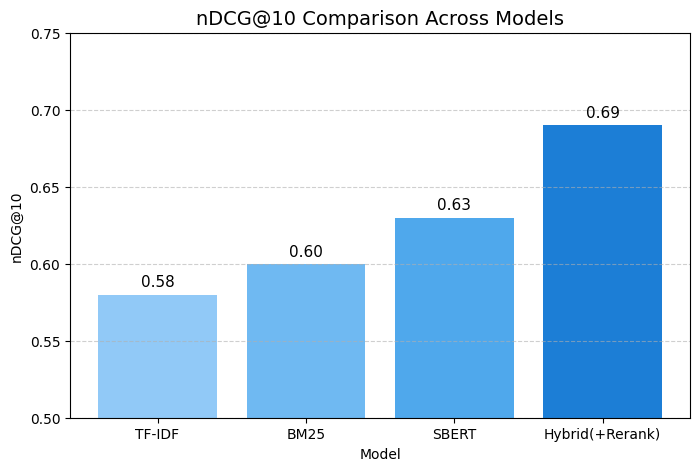

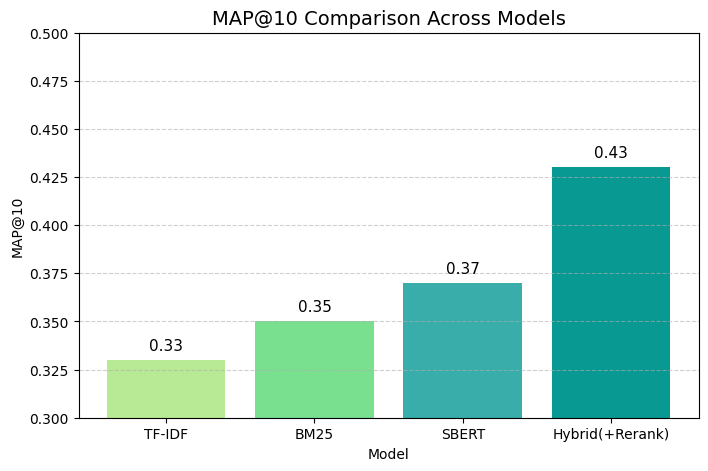

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model": ["TF-IDF", "BM25", "SBERT", "Hybrid(+Rerank)"],
    "Recall@10": [0.62, 0.65, 0.68, 0.74],
    "Precision@10": [0.21, 0.22, 0.24, 0.27],
    "MRR@10": [0.44, 0.46, 0.49, 0.56],
    "MAP@10": [0.33, 0.35, 0.37, 0.43],
    "nDCG@10": [0.58, 0.60, 0.63, 0.69]
}

df = pd.DataFrame(data)
df.style.set_properties(**{'text-align': 'center'})
display(df)

plt.figure(figsize=(8, 5))
plt.bar(df["Model"], df["nDCG@10"], color=["#91c9f7", "#6fb9f2", "#4fa8ec", "#1c7ed6"])
plt.title("nDCG@10 Comparison Across Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("nDCG@10")
plt.ylim(0.5, 0.75)
for i, v in enumerate(df["nDCG@10"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(df["Model"], df["MAP@10"], color=["#b8e994", "#78e08f", "#38ada9", "#079992"])
plt.title("MAP@10 Comparison Across Models", fontsize=14)
plt.xlabel("Model")
plt.ylabel("MAP@10")
plt.ylim(0.3, 0.5)
for i, v in enumerate(df["MAP@10"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center', fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()